# Introduction to the Tropical Abel--Jacobi Transform

Yueqi Cao, *Department of Mathematics, Imperial College London*

## Metric Graphs

In [1]:
import sys
from pathlib import Path

src_path = Path("../src") 
sys.path.append(str(src_path))

import mgraph
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

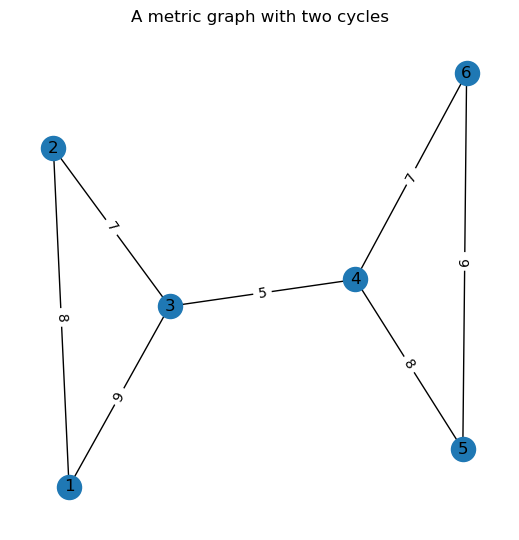

In [2]:
# define a weighted graph with two cycles
MG = mgraph.MetricGraph()
# first cycle 
MG.add_edge(2, 3, weight = 7)
MG.add_edge(1, 2, weight = 8)
MG.add_edge(1, 3, weight = 9)
# bridge edge of the graph
MG.add_edge(3, 4, weight = 5) 
# second cycle
MG.add_edge(5, 6, weight = 6)
MG.add_edge(6, 4, weight = 7)
MG.add_edge(4, 5, weight = 8)

# draw the weighted graph
plt.figure(figsize=(5,5))
pos = nx.spring_layout(MG, seed=1)
nx.draw(MG, pos, with_labels=True)   
edge_labels = nx.get_edge_attributes(MG,'weight') 
edge_dic = nx.draw_networkx_edge_labels(MG, pos, edge_labels=edge_labels)
plt.title("A metric graph with two cycles")
plt.show()

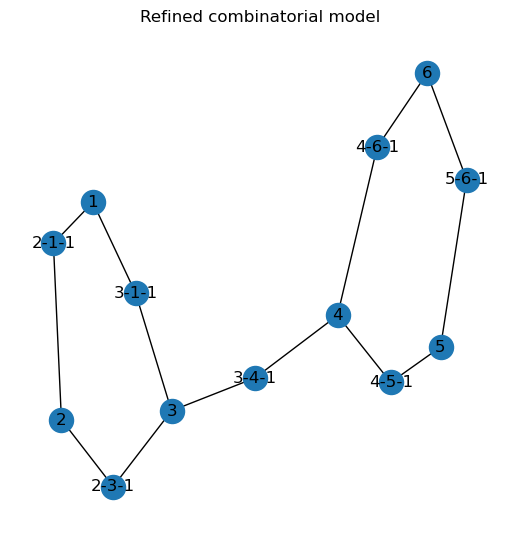

In [3]:
# refine a combinatorial model by edge subdivision
MG_disp = MG.copy()
MG_disp.edge_subdivision()

# draw the refined graph
plt.figure(figsize=(5,5))
pos = nx.spring_layout(MG_disp, seed=1)
nx.draw(MG_disp, pos, with_labels=True)   
plt.title("Refined combinatorial model")
plt.show()

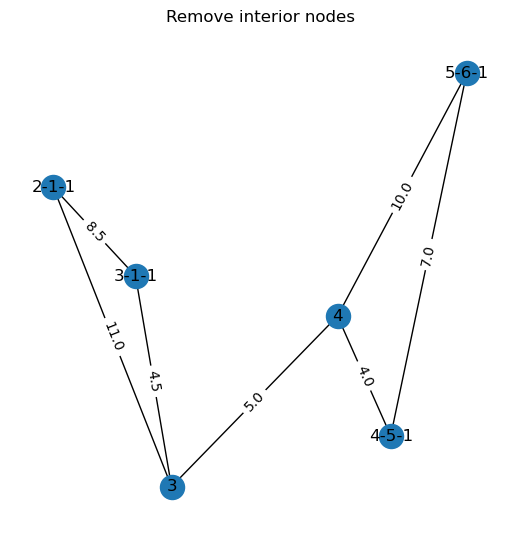

In [4]:
# simplify a combinatorial model by removing all interior nodes
MG_disp.remove_interior_nodes()

# draw the simplified graph
plt.figure(figsize=(5,5))
nx.draw(MG_disp, pos, with_labels=True) 
edge_labels = nx.get_edge_attributes(MG_disp,'weight') 
edge_dic = nx.draw_networkx_edge_labels(MG_disp, pos, edge_labels=edge_labels)  
plt.title("Remove interior nodes")
plt.show()

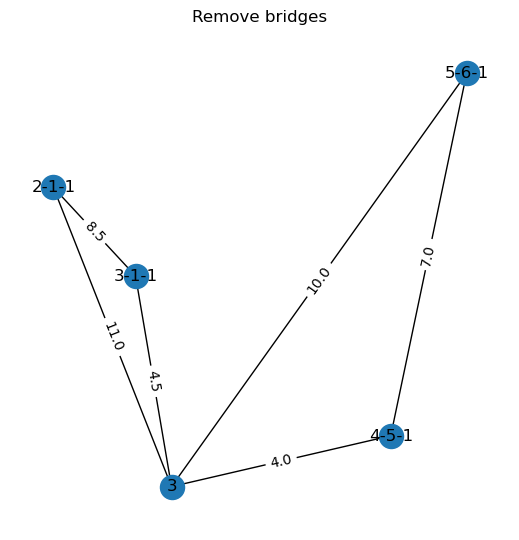

In [5]:
# simplify a combinatorial model by removing all bridges
MG_disp.remove_bridges()

# draw the simplified graph
plt.figure(figsize=(5,5))
nx.draw(MG_disp, pos, with_labels=True)   
edge_labels = nx.get_edge_attributes(MG_disp,'weight') 
edge_dic = nx.draw_networkx_edge_labels(MG_disp, pos, edge_labels=edge_labels)
plt.title("Remove bridges")
plt.show()

The minimal spanning tree of MG is [(2, 3), (2, 1), (3, 4), (4, 6), (5, 6)]



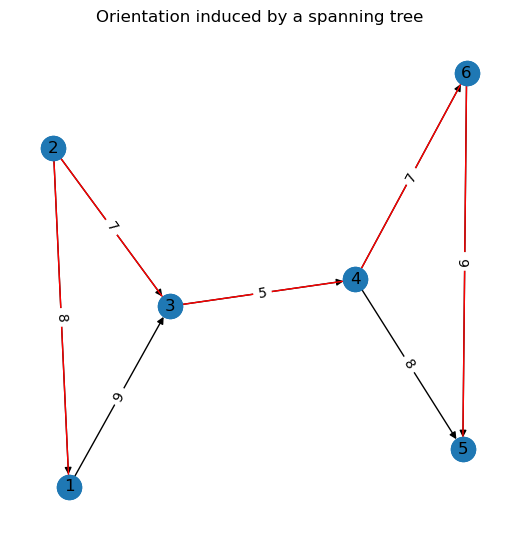

In [6]:
# compute the minimal spanning tree
MST = nx.minimum_spanning_tree(MG)
print("The minimal spanning tree of MG is {}\n".format(MST.edges()))

# orient the graph with respect to the tree MST
Directed_MG = MG.tree_orientation(MST)

# draw the weighted graph
plt.figure(figsize=(5,5))
pos = nx.spring_layout(MG, seed=1)
nx.draw(Directed_MG, pos, with_labels=True)
nx.draw(MST, pos, edge_color="red")
edge_labels = nx.get_edge_attributes(MG,'weight') 
pic = nx.draw_networkx_edge_labels(MG, pos, edge_labels=edge_labels)
plt.title("Orientation induced by a spanning tree")
plt.show()

In [7]:
# compute the homology basis of MG with respect to MST
homology_basis =  MG.homology_basis(MST)

g = len(homology_basis)
print("the genus of the metric graph is", g)
for i in range(g):
    print("cycle {} is: {}".format(i, homology_basis[i].edges(data=True)))

the genus of the metric graph is 2
cycle 0 is: [(1, 3, {'weight': 9, 'sign': 1}), (2, 1, {'weight': 8, 'sign': 1}), (2, 3, {'weight': 7, 'sign': -1})]
cycle 1 is: [(4, 5, {'weight': 8, 'sign': 1}), (4, 6, {'weight': 7, 'sign': -1}), (6, 5, {'weight': 6, 'sign': -1})]


In [8]:
# compute the cycle-edge incidence matrix
C = MG.cycle_edge(MST)
print("the cycle-edge incidence matrix is\n", C)

C_st = MG.reduced_cycle_edge(MST)
print("the reduced cycle-edge incidence matrix is\n", C_st)

the cycle-edge incidence matrix is
 [[-1.  1.  0.  1.  0.  0.  0.]
 [ 0.  0.  0.  0. -1.  1. -1.]]
the reduced cycle-edge incidence matrix is
 [[-1.  1.  0.  0.  0.]
 [ 0.  0.  0. -1. -1.]]


In [9]:
# compute the path-edge incidence matrix
# if the base point is chosen to be the first point of spanning tree
# then the path-edge incidence matrix will only contain 1 and 0
# since the spanning tree is oriented by depth

base_point = list(MST.nodes())[0]

Y = MG.path_edge(MST, base_point)
print("the path-edge incidence matrix is \n", Y)

Y_st = MG.reduced_path_edge(MST, base_point)
print("the reduced path-edge incidence matrix is \n", Y_st)

the path-edge incidence matrix is 
 [[0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [1. 0. 1. 0. 0. 0. 0.]
 [1. 0. 1. 0. 1. 0. 1.]
 [1. 0. 1. 0. 1. 0. 0.]]
the reduced path-edge incidence matrix is 
 [[0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [1. 0. 1. 0. 0.]
 [1. 0. 1. 1. 1.]
 [1. 0. 1. 1. 0.]]


In [10]:
# compute the tropical Abel--Jacobi transform and tropical polarization matrix

# use non-reduced matrices
C = MG.cycle_edge(MST)
L = MG.edge_length(MST)
Y = MG.path_edge(MST, base_point)

V = C @ L @ Y.T
Q = C @ L @ C.T
print("the tropical Abel--Jacobi transform of MG is (use non-reduced matrices)\n", V)
print("the tropical polarization matrix is (use non-reduced matrices)\n", Q)

# use reduced matrices
V_st = MG.trop_transform(MST, base_point)
Q_st = MG.trop_polarization(MST)
print("the tropical Abel--Jacobi transform of MG is (use reduced matrices)\n", V_st)
print("the tropical polarization matrix is (use reduced matrices)\n", Q_st)

the tropical Abel--Jacobi transform of MG is (use non-reduced matrices)
 [[  0.  -7.   8.  -7.  -7.  -7.]
 [  0.   0.   0.   0. -13.  -7.]]
the tropical polarization matrix is (use non-reduced matrices)
 [[24.  0.]
 [ 0. 21.]]
the tropical Abel--Jacobi transform of MG is (use reduced matrices)
 [[  0.  -7.   8.  -7.  -7.  -7.]
 [  0.   0.   0.   0. -13.  -7.]]
the tropical polarization matrix is (use reduced matrices)
 [[24.  0.]
 [ 0. 21.]]


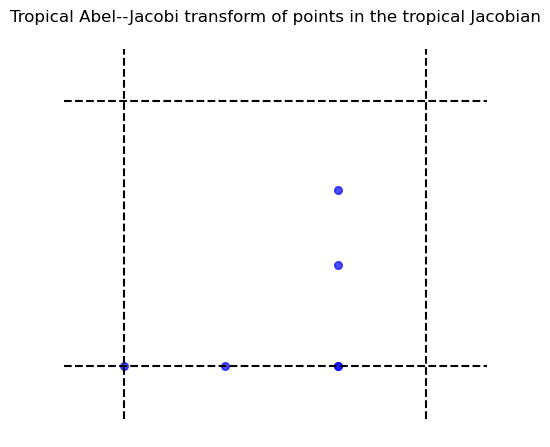

In [11]:
# draw the vectors in the tropical Jacobian
from tropdist import draw_lattice_2D, translate_to_fundamental_domain

fig, ax = plt.subplots(figsize=(6,6))
draw_lattice_2D(Q, ax)
# translate the vectors for better visualization
Vr = translate_to_fundamental_domain(V, Q)
ax.scatter(Vr[0,:], Vr[1,:], color='blue', s=30, alpha=0.7)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title("Tropical Abel--Jacobi transform of points in the tropical Jacobian")
plt.show()

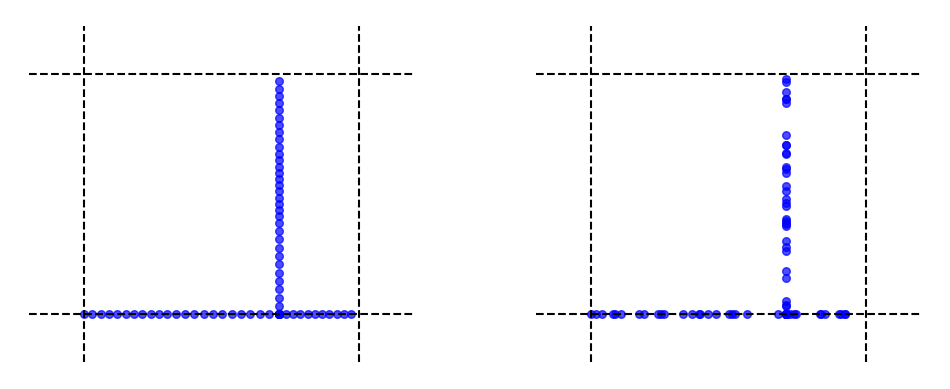

In [12]:
# interpolate points in the metric graph

# equidistant interpolation
ratio = 10
V_eq = MG.interpolate(MST, V, ratio, method="equidistant")
V_rand = MG.interpolate(MST, V, ratio, method="random")

fig, axes = plt.subplots(1,2, figsize=(12,6))

# subplot for equidistant interpolation
draw_lattice_2D(Q, axes[0])
Vr = translate_to_fundamental_domain(V_eq, Q)
axes[0].scatter(Vr[0,:], Vr[1,:], color='blue', s=30, alpha=0.7)
axes[0].set_aspect('equal')
axes[0].axis('off')

# subplot for random interpolation
draw_lattice_2D(Q, axes[1])
Vr = translate_to_fundamental_domain(V_rand, Q)
axes[1].scatter(Vr[0,:], Vr[1,:], color='blue', s=30, alpha=0.7)
axes[1].set_aspect('equal')
axes[1].axis('off')

plt.show()